In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [158]:
vehicle_data = pd.read_csv('dataset.csv')

In [159]:
vehicle_data = vehicle_data[vehicle_data['price'] > 0]

In [160]:
vehicle_data.head()

,name,description,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
0,2024 Jeep Wagoneer Series II,"\n \n Heated Leather Seats, Nav Sy...",Jeep,Wagoneer,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,White,Global Black,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,Al West is committed to offering every custome...,Jeep,Grand Cherokee,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Metallic,Global Black,Four-wheel Drive
2,2024 GMC Yukon XL Denali,NaN,GMC,Yukon XL,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Summit White,Teak/Light Shale,Four-wheel Drive
3,2023 Dodge Durango Pursuit,White Knuckle Clearcoat 2023 Dodge Durango Pur...,Dodge,Durango,2023,46835.0,16V MPFI OHV,8.0,Gasoline,32.0,8-Speed Automatic,Pursuit,SUV,4.0,White Knuckle Clearcoat,Black,All-wheel Drive
4,2024 RAM 3500 Laramie,\n \n 2024 Ram 3500 Laramie Billet...,RAM,3500,2024,81663.0,24V DDI OHV Turbo Diesel,6.0,Diesel,10.0,6-Speed Automatic,Laramie,Pickup Truck,4.0,Silver,Black,Four-wheel Drive


In [161]:
vehicle_data.drop(columns=['description','cylinders','doors','interior_color','exterior_color'], inplace=True)

In [162]:
vehicle_data.head()

,name,make,model,year,price,engine,fuel,mileage,transmission,trim,body,drivetrain
0,2024 Jeep Wagoneer Series II,Jeep,Wagoneer,2024,74600.0,24V GDI DOHC Twin Turbo,Gasoline,10.0,8-Speed Automatic,Series II,SUV,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,Jeep,Grand Cherokee,2024,50170.0,OHV,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,Four-wheel Drive
2,2024 GMC Yukon XL Denali,GMC,Yukon XL,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",Gasoline,0.0,Automatic,Denali,SUV,Four-wheel Drive
3,2023 Dodge Durango Pursuit,Dodge,Durango,2023,46835.0,16V MPFI OHV,Gasoline,32.0,8-Speed Automatic,Pursuit,SUV,All-wheel Drive
4,2024 RAM 3500 Laramie,RAM,3500,2024,81663.0,24V DDI OHV Turbo Diesel,Diesel,10.0,6-Speed Automatic,Laramie,Pickup Truck,Four-wheel Drive


In [163]:
vehicle_data.shape

(978, 12)

In [164]:
vehicle_data.describe()

,year,price,mileage
count,978.000000,978.000000,944.000000
mean,2023.916155,50254.317996,67.404661
std,0.298623,18640.823226,511.107283
min,2023.000000,17994.000000,0.000000
25%,2024.000000,36633.500000,4.000000
50%,2024.000000,47170.000000,8.000000
75%,2024.000000,58924.750000,13.000000
max,2025.000000,195895.000000,9711.000000


Pre-processing

In [165]:
vehicle_data.isnull().sum()

name             0
make             0
model            0
year             0
price            0
engine           2
fuel             7
mileage         34
transmission     2
trim             1
body             3
drivetrain       0
dtype: int64

In [166]:
vehicle_data.dropna(subset=['price'], inplace=True)

In [167]:
vehicle_data['mileage'].fillna(vehicle_data['mileage'].median(), inplace=True)

C:\Users\malsh\AppData\Local\Temp\ipykernel_1344\577170548.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  vehicle_data['mileage'].fillna(vehicle_data['mileage'].median(), inplace=True)


In [168]:
cat_cal = ['fuel','transmission','body']
for col in cat_cal:
    vehicle_data[col].fillna(vehicle_data[col].mode()[0], inplace=True)

C:\Users\malsh\AppData\Local\Temp\ipykernel_1344\606675576.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  vehicle_data[col].fillna(vehicle_data[col].mode()[0], inplace=True)


In [169]:
vehicle_data['engine'].fillna('Unknown', inplace=True)
vehicle_data['trim'].fillna('Unknown', inplace=True)

C:\Users\malsh\AppData\Local\Temp\ipykernel_1344\3387783798.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  vehicle_data['engine'].fillna('Unknown', inplace=True)
C:\Users\malsh\AppData\Local\Temp\ipykernel_1344\3387783798.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [170]:
vehicle_data.isnull().sum()

name            0
make            0
model           0
year            0
price           0
engine          0
fuel            0
mileage         0
transmission    0
trim            0
body            0
drivetrain      0
dtype: int64

In [171]:
vehicle_data.shape

(978, 12)

In [172]:
vehicle_data.duplicated().sum()

np.int64(57)

In [173]:
vehicle_data.drop_duplicates(inplace=True)

In [174]:
vehicle_data.shape

(921, 12)

In [175]:
vehicle_data

,name,make,model,year,price,engine,fuel,mileage,transmission,trim,body,drivetrain
0,2024 Jeep Wagoneer Series II,Jeep,Wagoneer,2024,74600.0,24V GDI DOHC Twin Turbo,Gasoline,10.0,8-Speed Automatic,Series II,SUV,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,Jeep,Grand Cherokee,2024,50170.0,OHV,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,Four-wheel Drive
2,2024 GMC Yukon XL Denali,GMC,Yukon XL,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",Gasoline,0.0,Automatic,Denali,SUV,Four-wheel Drive
3,2023 Dodge Durango Pursuit,Dodge,Durango,2023,46835.0,16V MPFI OHV,Gasoline,32.0,8-Speed Automatic,Pursuit,SUV,All-wheel Drive
4,2024 RAM 3500 Laramie,RAM,3500,2024,81663.0,24V DDI OHV Turbo Diesel,Diesel,10.0,6-Speed Automatic,Laramie,Pickup Truck,Four-wheel Drive
...,...,...,...,...,...,...,...,...,...,...,...,...
996,2024 RAM 2500 Tradesman,RAM,2500,2024,69315.0,24V DDI OHV Turbo Diesel,Diesel,0.0,Automatic,Tradesman,Pickup Truck,Four-wheel Drive
997,2024 Mercedes-Benz Sprinter 2500 Standard Roof,Mercedes-Benz,Sprinter 2500,2024,59037.0,16V DDI DOHC Turbo Diesel,Diesel,10.0,9-Speed Automatic,Standard Roof,Cargo Van,Rear-wheel Drive
999,2024 Jeep Wagoneer Base,Jeep,Wagoneer,2024,69085.0,24V GDI DOHC Twin Turbo,Gasoline,20.0,8-Speed Automatic,Base,SUV,Four-wheel Drive
1000,2024 Nissan Murano SV Intelligent AWD,Nissan,Murano,2024,43495.0,"6 DOHC, variable valve control, regular unlead...",Gasoline,6.0,Automatic,SV Intelligent AWD,SUV,All-wheel Drive


In [176]:
vehicle_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 921 entries, 0 to 1001
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          921 non-null    object 
 1   make          921 non-null    object 
 2   model         921 non-null    object 
 3   year          921 non-null    int64  
 4   price         921 non-null    float64
 5   engine        921 non-null    object 
 6   fuel          921 non-null    object 
 7   mileage       921 non-null    float64
 8   transmission  921 non-null    object 
 9   trim          921 non-null    object 
 10  body          921 non-null    object 
 11  drivetrain    921 non-null    object 
dtypes: float64(2), int64(1), object(9)
memory usage: 93.5+ KB


EDA

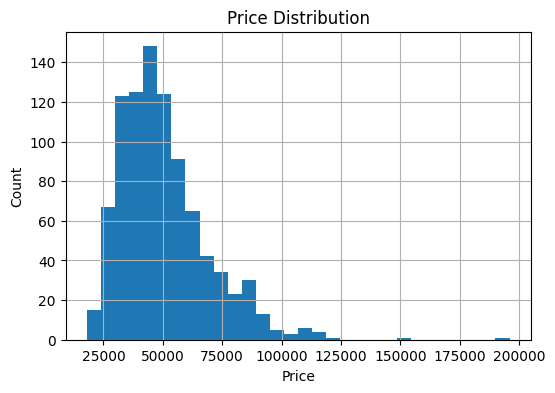

In [177]:

plt.figure(figsize=(6,4))
vehicle_data['price'].hist(bins=30)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

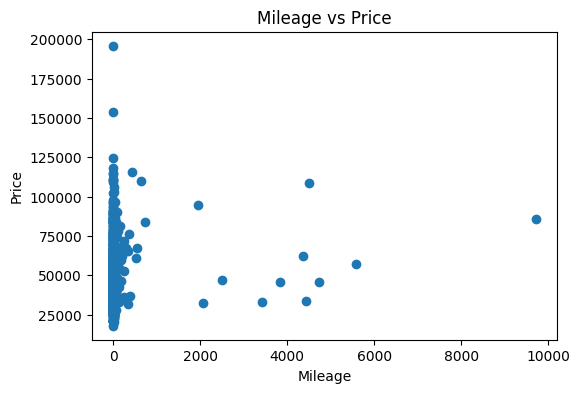

In [178]:
plt.figure(figsize=(6,4))
plt.scatter(vehicle_data['mileage'], vehicle_data['price'])
plt.title('Mileage vs Price')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

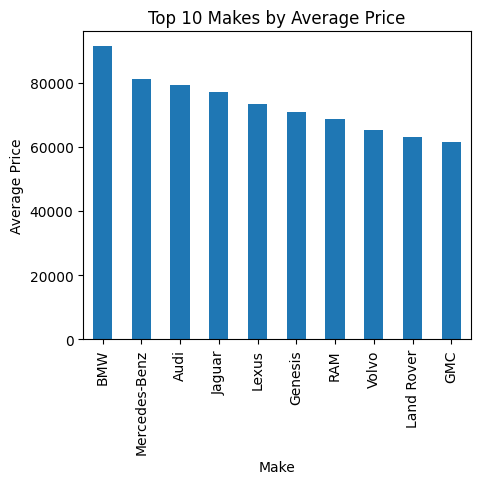

In [179]:
make_price = vehicle_data.groupby('make')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(5,4))
make_price.plot(kind='bar')
plt.title('Top 10 Makes by Average Price')
plt.xlabel('Make')
plt.ylabel('Average Price')
plt.show()

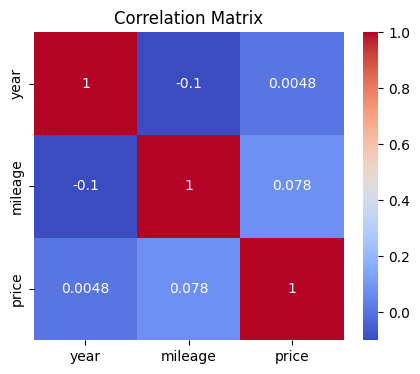

In [180]:

plt.figure(figsize=(5,4))
sns.heatmap(vehicle_data[['year','mileage','price']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Encoding

In [181]:
for col in vehicle_data.columns:
    print(f"{col}: {vehicle_data[col].nunique()} unique values")

name: 353 unique values
make: 28 unique values
model: 150 unique values
year: 3 unique values
price: 858 unique values
engine: 100 unique values
fuel: 7 unique values
mileage: 91 unique values
transmission: 38 unique values
trim: 198 unique values
body: 8 unique values
drivetrain: 4 unique values


In [182]:
for col in vehicle_data.columns:
    print(f"\n{col}")
    print(vehicle_data[col].unique()[:10])


name
['2024 Jeep Wagoneer Series II' '2024 Jeep Grand Cherokee Laredo'
 '2024 GMC Yukon XL Denali' '2023 Dodge Durango Pursuit'
 '2024 RAM 3500 Laramie' '2024 Nissan Murano Platinum'
 '2024 Jeep Wagoneer Base' '2024 Ford F-350 Lariat Super Duty'
 '2024 Hyundai Tucson Hybrid Limited' '2024 Jeep Grand Cherokee Altitude']

make
['Jeep' 'GMC' 'Dodge' 'RAM' 'Nissan' 'Ford' 'Hyundai' 'Chevrolet'
 'Volkswagen' 'Chrysler']

model
['Wagoneer' 'Grand Cherokee' 'Yukon XL' 'Durango' '3500' 'Murano' 'F-350'
 'Tucson Hybrid' 'Compass' 'Santa Cruz']

year
[2024 2023 2025]

price
[74600. 50170. 96410. 46835. 81663. 46000. 63862. 89978. 42230. 42773.]

engine
['24V GDI DOHC Twin Turbo' 'OHV'
 '6.2L V-8 gasoline direct injection, variable valve contr' '16V MPFI OHV'
 '24V DDI OHV Turbo Diesel' '24V MPFI DOHC' '32V DDI OHV Turbo Diesel'
 '16V GDI DOHC Turbo Hybrid'
 'ar 3.6L V-6 DOHC, variable valve control, regular unleade'
 '16V GDI DOHC Turbo']

fuel
['Gasoline' 'Diesel' 'Hybrid' 'Electric' 'E85 Flex

In [183]:
vehicle_data = vehicle_data.drop(['name','trim', 'engine'], axis=1)

In [184]:
vehicle_data_encoded = pd.get_dummies(
    vehicle_data,
    columns=['make', 'model', 'fuel', 'transmission', 'body', 'drivetrain'],
    drop_first=True
)

In [185]:
vehicle_data_encoded

,year,price,mileage,make_Audi,make_BMW,make_Buick,make_Cadillac,make_Chevrolet,make_Chrysler,make_Dodge,...,body_Convertible,body_Hatchback,body_Minivan,body_Passenger Van,body_Pickup Truck,body_SUV,body_Sedan,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive
0,2024,74600.0,10.0,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,2024,50170.0,1.0,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
2,2024,96410.0,0.0,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
3,2023,46835.0,32.0,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
4,2024,81663.0,10.0,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,2024,69315.0,0.0,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
997,2024,59037.0,10.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
999,2024,69085.0,20.0,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1000,2024,43495.0,6.0,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


Model Training

In [186]:
input_data = vehicle_data_encoded.drop(columns=['price'])
output_data = vehicle_data_encoded['price']

In [187]:
input_data.shape

(921, 231)

In [188]:
x_train, x_test, y_train, y_test = train_test_split(
    input_data,
    output_data,
    test_size=0.2,
    random_state=42
    
)

In [189]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [190]:
y_pred = model.predict(x_test)

In [191]:
y_pred

array([ 37167.91325711,  75107.72549423,  48327.43561624,  35896.83313977,
        34748.95403407,  34304.99999996,  75053.951427  ,  52649.32042371,
        72828.1966583 ,  43839.51095522,  81135.40162869,  81137.20558235,
        72830.45160037,  60388.65240706,  80994.28553896,  72476.11447528,
        47610.61779148,  46040.79185565,  38913.47630523,  52651.57536578,
        33959.50853793,  72826.39270464,  46621.99999989,  44578.56708594,
        49130.89575893,  41006.5526492 ,  74626.17484019,  33963.56743366,
        48821.09802336,  52650.22240054,  98819.95110686,  31914.39563   ,
        31690.84982049,  57572.51740861,  56525.27450583,  40663.2856851 ,
        25917.26609819,  59025.19849308,  37626.69584185,  63375.86403064,
        74633.84164323,  49131.34674735,  31370.86348064,  46970.29452891,
        76928.67390247,  33343.09597177,  27077.97055223,  38913.47630523,
        58924.16790352,  33338.13509921,  63285.57502956,  29271.45832806,
        73224.37337213,  

In [192]:
x_train.head(1)

,year,mileage,make_Audi,make_BMW,make_Buick,make_Cadillac,make_Chevrolet,make_Chrysler,make_Dodge,make_Ford,...,body_Convertible,body_Hatchback,body_Minivan,body_Passenger Van,body_Pickup Truck,body_SUV,body_Sedan,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive
493,2024,25.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [193]:
sample = pd.DataFrame([{
    'year': 2024,
    'mileage': 15,
    'make_BMW': 0,
    'make_Audi': 1,
    'make_Jeep': 0,
    'fuel_Gasoline': 1,
    'fuel_Diesel': 0,
    'body_SUV': 1,
    'drivetrain_Four-wheel Drive': 1,
   
}])

In [194]:
sample = sample.reindex(columns=input_data.columns, fill_value=0)

In [195]:
sample

,year,mileage,make_Audi,make_BMW,make_Buick,make_Cadillac,make_Chevrolet,make_Chrysler,make_Dodge,make_Ford,...,body_Convertible,body_Hatchback,body_Minivan,body_Passenger Van,body_Pickup Truck,body_SUV,body_Sedan,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive
0,2024,15,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0


In [196]:
price = model.predict(sample)[0]
print(price)

80972.17565152002


In [197]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

y_pred = model.predict(x_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(((y_test - y_pred) ** 2).mean()))
print("R²:", r2_score(y_test, y_pred))

MAE: 5415.647232618639
RMSE: 8925.44328821777
R²: 0.7451298949743637


In [201]:
import joblib

joblib.dump(model, "vehicle_price_model.pkl")
joblib.dump(input_data.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']